In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import requests
%matplotlib inline 

In [2]:
def download(url, filename):
    response = requests.get(url)
    if response.status_code == 200:
        with open (filename, 'w', encoding='utf-8') as f:
            f.write(response.text)
    else:
        print('Download failed', response.status_code)

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-SkillsNetwork/labs/Data%20files/automobileEDA.csv"
filename = 'EDA_cars.csv'

download(url, filename)

df = pd.read_csv(filename)

In [3]:
numeric_fields = df.select_dtypes(include=['int64', 'float64'])
numeric_fields.corr()

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,diesel,gas
symboling,1.000000,0.466264,-0.535987,-0.365404,-0.242423,-0.550160,-0.233118,-0.110581,-0.140019,-0.008245,-0.182196,0.075819,0.279740,-0.035527,0.036233,-0.082391,0.066171,-0.196735,0.196735
normalized-losses,0.466264,1.000000,-0.056661,0.019424,0.086802,-0.373737,0.099404,0.112360,-0.029862,0.055563,-0.114713,0.217299,0.239543,-0.225016,-0.181877,0.133999,0.238567,-0.101546,0.101546
wheel-base,-0.535987,-0.056661,1.000000,0.876024,0.814507,0.590742,0.782097,0.572027,0.493244,0.158502,0.250313,0.371147,-0.360305,-0.470606,-0.543304,0.584642,0.476153,0.307237,-0.307237
length,-0.365404,0.019424,0.876024,1.000000,0.857170,0.492063,0.880665,0.685025,0.608971,0.124139,0.159733,0.579821,-0.285970,-0.665192,-0.698142,0.690628,0.657373,0.211187,-0.211187
width,-0.242423,0.086802,0.814507,0.857170,1.000000,0.306002,0.866201,0.729436,0.544885,0.188829,0.189867,0.615077,-0.245800,-0.633531,-0.680635,0.751265,0.673363,0.244356,-0.244356
height,-0.550160,-0.373737,0.590742,0.492063,0.306002,1.000000,0.307581,0.074694,0.180449,-0.062704,0.259737,-0.087027,-0.309974,-0.049800,-0.104812,0.135486,0.003811,0.281578,-0.281578
curb-weight,-0.233118,0.099404,0.782097,0.880665,0.866201,0.307581,1.000000,0.849072,0.644060,0.167562,0.156433,0.757976,-0.279361,-0.749543,-0.794889,0.834415,0.785353,0.221046,-0.221046
engine-size,-0.110581,0.112360,0.572027,0.685025,0.729436,0.074694,0.849072,1.000000,0.572609,0.209523,0.028889,0.822676,-0.256733,-0.650546,-0.679571,0.872335,0.745059,0.070779,-0.070779
bore,-0.140019,-0.029862,0.493244,0.608971,0.544885,0.180449,0.644060,0.572609,1.000000,-0.055390,0.001263,0.566936,-0.267392,-0.582027,-0.591309,0.543155,0.554610,0.054458,-0.054458
stroke,-0.008245,0.055563,0.158502,0.124139,0.188829,-0.062704,0.167562,0.209523,-0.055390,1.000000,0.187923,0.098462,-0.065713,-0.034696,-0.035201,0.082310,0.037300,0.241303,-0.241303


In [4]:
df[['bore', 'stroke', 'compression-ratio', 'horsepower']].corr()

,bore,stroke,compression-ratio,horsepower
bore,1.000000,-0.055390,0.001263,0.566936
stroke,-0.055390,1.000000,0.187923,0.098462
compression-ratio,0.001263,0.187923,1.000000,-0.214514
horsepower,0.566936,0.098462,-0.214514,1.000000


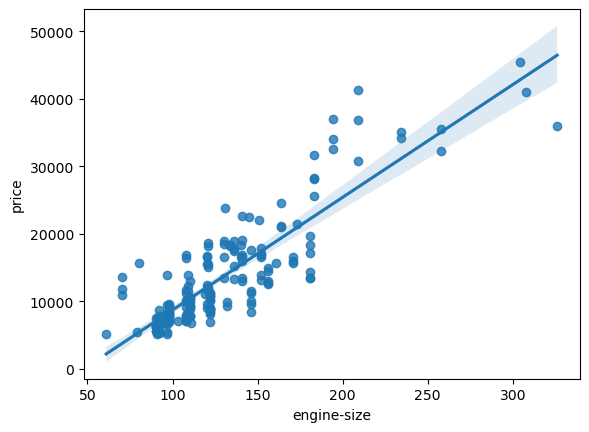

,engine-size,price
engine-size,1.000000,0.872335
price,0.872335,1.000000


In [5]:
sns.regplot(x="engine-size", y="price", data=df)
plt.show()
df[['engine-size', 'price']].corr()

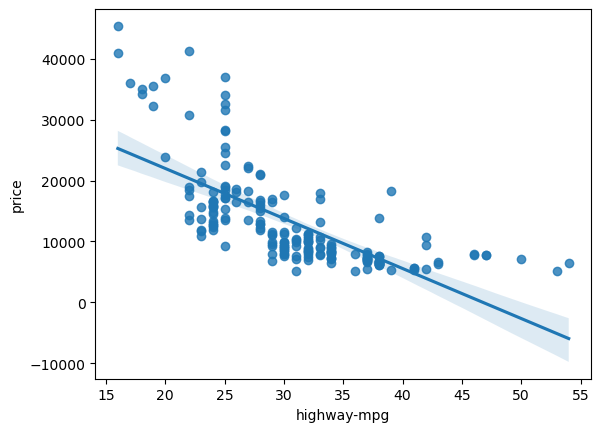

,highway-mpg,price
highway-mpg,1.000000,-0.704692
price,-0.704692,1.000000


In [6]:
sns.regplot(x='highway-mpg', y='price', data=df)
plt.show()
df[['highway-mpg', 'price']].corr()

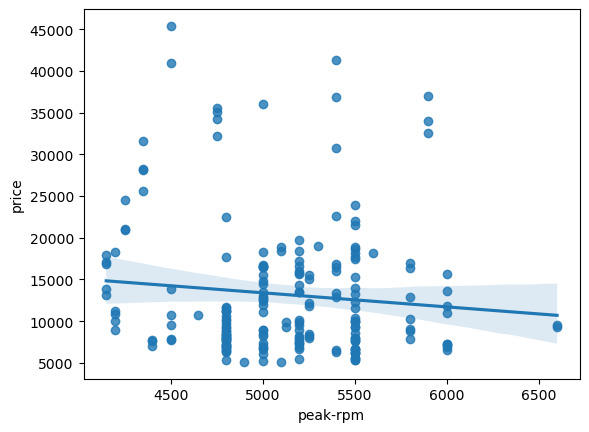

,peak-rpm,price
peak-rpm,1.000000,-0.101616
price,-0.101616,1.000000


In [7]:
sns.regplot(x="peak-rpm", y="price", data=df)
plt.show()
df[['peak-rpm', 'price']].corr()

In [46]:
fig = px.box(df, x='body-style', y='price', 
             title='Price variance across Body-style', 
             color_discrete_sequence=['red'])
fig.show()

fig = px.box(df, x='engine-location', y='price', 
             title='Price variance across Engine-location', 
             color_discrete_sequence=['green'])
fig.show()

fig = px.box(df, x='drive-wheels', y='price', 
             title='Price variance across Drive-wheels', 
             color_discrete_sequence=['orange'])
fig.show()

In [10]:
df.describe(include=['object'])

,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,engine-type,num-of-cylinders,fuel-system,horsepower-binned
count,201,201,201,201,201,201,201,201,201,200
unique,22,2,2,5,3,2,6,7,8,3
top,toyota,std,four,sedan,fwd,front,ohc,four,mpfi,Low
freq,32,165,115,94,118,198,145,157,92,115


In [17]:
drive_wheels_counts = df['drive-wheels'].value_counts()
drive_wheels_counts

drive_wheels_counts = df['drive-wheels'].value_counts().to_frame()
drive_wheels_counts.reset_index(inplace=True)
drive_wheels_counts = drive_wheels_counts.rename(columns={'drive_wheels': 'value_counts'})
drive_wheels_counts

,drive-wheels,count
0,fwd,118
1,rwd,75
2,4wd,8


In [25]:
engine_loc_counts = df['engine-location'].value_counts().to_frame()
engine_loc_counts.reset_index(inplace=True)
engine_loc_counts.rename(columns={'engine-location': 'value_counts'}, inplace=True)
engine_loc_counts

,value_counts,count
0,front,198
1,rear,3


In [31]:
df['drive-wheels'].unique()
df_group_one = df[['drive-wheels','body-style','price']]
df_grouped = df_group_one.groupby(['drive-wheels'], as_index=False).agg({'price': 'mean'})
df_grouped

group_1 = df_group_one.groupby(['drive-wheels', 'body-style'], as_index=False).mean()
group_1

group_pivot = group_1.pivot(index='drive-wheels', columns='body-style', values='price')
group_pivot

body-style,convertible,hardtop,hatchback,sedan,wagon
drive-wheels,,,,,
4wd,NaN,NaN,7603.000000,12647.333333,9095.750000
fwd,11595.0,8249.000000,8396.387755,9811.800000,9997.333333
rwd,23949.6,24202.714286,14337.777778,21711.833333,16994.222222


### Understanding P-value Levels

The **p-value** measures how likely it is that the observed relationship happened by random chance.

| P-value Range | Interpretation | Meaning |
|----------------|----------------|----------|
| p ≥ 0.10 | Not significant | No evidence of a relationship |
| 0.05 ≤ p < 0.10 | Marginally significant | Weak evidence of a relationship |
| 0.01 ≤ p < 0.05 | Statistically significant | Moderate evidence — likely a real relationship |
| 0.001 ≤ p < 0.01 | Highly significant | Strong evidence that the relationship is real |
| p < 0.001 | Very highly significant | Extremely strong evidence — almost certainly real |

**Key takeaway:**  
- The smaller the p-value, the stronger the evidence against the null hypothesis (i.e., the stronger the evidence that a real relationship exists).  
- By convention:
  - `p < 0.05` → considered significant  
  - `p < 0.001` → considered very strong evidence


### Pearson Correlation Coefficient (r)

- The Pearson correlation (r) measures **the strength and direction** of a **linear relationship** between two variables.
- Values range from **-1 to +1**:
  - **+1** → perfect positive correlation  
  - **0** → no linear correlation  
  - **-1** → perfect negative correlation
- Rule of thumb for strength:
  - 0.0–0.3 → weak
  - 0.3–0.7 → moderate
  - 0.7-1 → strong

### P-value + Pearson Correlation

- **Pearson r** tells us *how strong and in what direction* the relationship is.  
- **P-value** tells us *whether that relationship is statistically real or just random*.  

Together:
- A **low p-value** + **high |r|** → strong, significant relationship  
- A **low p-value** + **low |r|** → weak but real relationship  
- A **high p-value** → no statistically significant relationship, regardless of r


In [ ]:
from scipy import stats

pearson_coef, p_value = stats.pearsonr(df['wheel-base'], df['price'])
print("\nRelationship between Wheel-base & Price")
print(f"The Pearson Correlation Coefficient is {pearson_coef:.3f}, with a P-value of P = {p_value:.2e}") 
# The correlation between wheel-base and price is statistically significant (p < 0.001),
# but the linear relationship is moderately positive (~0.59).

pearson_coef, p_value = stats.pearsonr(df['horsepower'], df['price'])
print("\nRelationship between Horsepower & Price")
print(f"The Pearson Correlation Coefficient is {pearson_coef:.3f}, with a P-value of P = {p_value:.2e}") 
# The correlation between horsepower and price is statistically significant (p < 0.001)
# and the relationship is strongly positive (~ 0.81)

pearson_coef, p_value = stats.pearsonr(df['length'], df['price'])
print("\nRelationship between Length & Price")
print(f"The Pearson Correlation Coefficient is {pearson_coef:.3f}, with a P-value of P = {p_value:.2e}")
# The correlation between length and price is statistically significant (p < 0.001)
# and the relationship is moderately positive (~ 0.69)

pearson_coef, p_value = stats.pearsonr(df['width'], df['price'])
print("\nRelationship between Width & Price")
print(f"The Pearson Correlation Coefficient is {pearson_coef:.3f}, with a P-value of P = {p_value:.2e}")
# The correlation between width and price is statistically significant (p < 0.001)
# and the relationship is strongly positive (~ 0.75)

pearson_coef, p_value = stats.pearsonr(df['curb-weight'], df['price'])
print("\nRelationship between Curb-weight & Price")
print(f"The Pearson Correlation Coefficient is {pearson_coef:.3f}, with a P-value of P = {p_value:.2e}")
# The correlation between curb-weight and price is statistically significant (p < 0.001)
# and the relationship is strongly positive (~ 0.83)

pearson_coef, p_value = stats.pearsonr(df['engine-size'], df['price'])
print("\nRelationship between Engine-size & Price")
print(f"The Pearson Correlation Coefficient is {pearson_coef:.3f}, with a P-value of P = {p_value:.2e}")
# The correlation between engine-size and price is statistically significant (p < 0.001)
# and the relationship is strongly positive (~ 0.87)

pearson_coef, p_value = stats.pearsonr(df['bore'], df['price'])
print("\nRelationship between Bore & Price")
print(f"The Pearson Correlation Coefficient is {pearson_coef:.3f}, with a P-value of P = {p_value:.2e}")
# The correlation between bore and price is statistically significant (p < 0.001)
# and the relationship is moderately positive (~ 0.54)

pearson_coef, p_value = stats.pearsonr(df['city-mpg'], df['price'])
print("\nRelationship between City-mpg & Price")
print(f"The Pearson Correlation Coefficient is {pearson_coef:.3f}, with a P-value of P = {p_value:.2e}")
# The correlation between city-mpg and price is statistically significant (p < 0.001)
# and the relationship is moderately negative (~ -0.69)

pearson_coef, p_value = stats.pearsonr(df['highway-mpg'], df['price'])
print("\nRelationship between Highway-mpg & Price")
print(f"The Pearson Correlation Coefficient is {pearson_coef:.3f}, with a P-value of P = {p_value:.2e}")
# The correlation between highway-mpg and price is statistically significant (p < 0.001)
# and the relationship is moderately negative (~ -0.71)


Relationship between Wheel-base & Price
The Pearson Correlation Coefficient is 0.585, with a P-value of P = 8.08e-20

Relationship between Horsepower & Price
The Pearson Correlation Coefficient is 0.810, with a P-value of P = 6.37e-48

Relationship between Length & Price
The Pearson Correlation Coefficient is 0.691, with a P-value of P = 8.02e-30

Relationship between Width & Price
The Pearson Correlation Coefficient is 0.751, with a P-value of P = 9.20e-38

Relationship between Curb-weight & Price
The Pearson Correlation Coefficient is 0.834, with a P-value of P = 2.19e-53

Relationship between Engine-size & Price
The Pearson Correlation Coefficient is 0.872, with a P-value of P = 9.27e-64

Relationship between Bore & Price
The Pearson Correlation Coefficient is 0.543, with a P-value of P = 8.05e-17

Relationship between City-mpg & Price
The Pearson Correlation Coefficient is -0.687, with a P-value of P = 2.32e-29

Relationship between Highway-mpg & Price
The Pearson Correlation Coef